#THUC HANH ANN MODEL

In [4]:
#install required libraties
import pandas as pd
import numpy as np
#data visualization packages
import matplotlib.pyplot as plt
#keras packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
# KerasClassifier has moved to scikeras.wrappers
# If you haven't installed scikeras, you can do so by running: !pip install scikeras
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout
#model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

In [3]:
!pip install scikeras

In [5]:
#download mnist fashion dataset
fasion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fasion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [6]:
#reshape data from 3-D to 2-D array
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

#feature scaling
minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


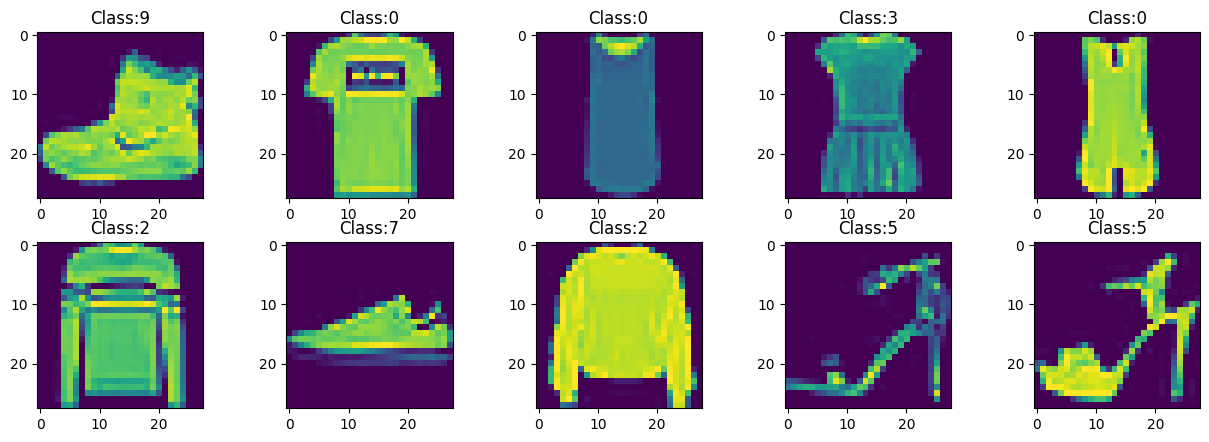

In [7]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(wspace=0.5)
plt.show()

In [9]:
#initial ANN model
fasion_model = Sequential()

#add first hidden layer
fasion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

#add output layer
fasion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

#compile neural network
fasion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#model summary
fasion_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#train ANN model
model_fit = fasion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8222 - loss: 0.5045 - val_accuracy: 0.8585 - val_loss: 0.4006
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8650 - loss: 0.3713 - val_accuracy: 0.8697 - val_loss: 0.3647
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8785 - loss: 0.3327 - val_accuracy: 0.8683 - val_loss: 0.3641
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8861 - loss: 0.3088 - val_accuracy: 0.8785 - val_loss: 0.3473
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8935 - loss: 0.2882 - val_accuracy: 0.8703 - val_loss: 0.3502
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8988 - loss: 0.2720 - val_accuracy: 0.8788 - val_loss: 0.3403
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9038 - loss: 0.2596 - val_accuracy: 0.8828 - val_loss: 0.3262
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9068 - loss: 0

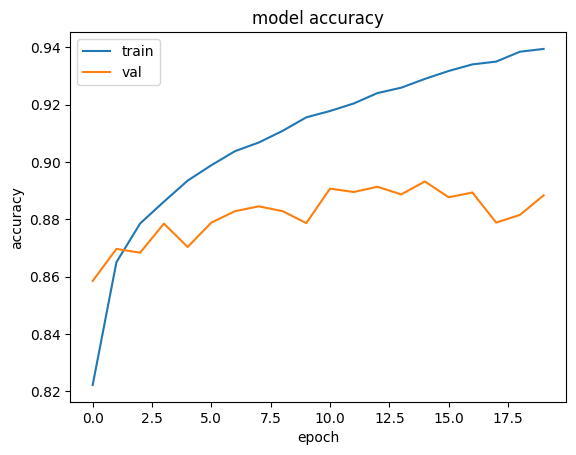

In [12]:
#Danh gia ANN model accuracy
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

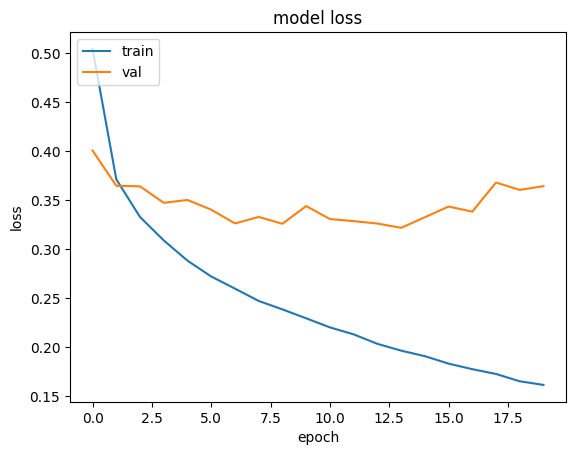

In [13]:
#Danh gia ANN model loss
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [14]:
#du bao anh moi
print(np.argmax(fasion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fasion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [16]:
mnist_train_path = '/content/sample_data/mnist_train_small.csv'
mnist_test_path = '/content/sample_data/mnist_test.csv'

mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)
print(mnist_train.head())
print(mnist_train.shape)

   6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.584  0.585  0.586  0.587  0.588  0.589  0.590  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
(19999, 785)


In [17]:
X_train = mnist_train.iloc[:,1:]
X_test = mnist_test.iloc[:,1:]
print(X_train.shape)
y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

(19999, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [18]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense


In [20]:
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_fit = model.fit(X_train, y_train, epochs=30, verbose = 1)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8756 - loss: 1.1798
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9366 - loss: 0.2324
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9483 - loss: 0.1908
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9504 - loss: 0.2009
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9418 - loss: 0.2620
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9582 - loss: 0.1762
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9565 - loss: 0.2033
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9574 - loss: 0.2017
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9607 - loss: 0.1847
Epoch 10/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9639 - loss: 0.1793
Epoch 11/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9686 - loss: 0.1759
Epoch 12/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

In [22]:
print(np.argmax(model.predict(X_test)[0]), y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2 2


In [27]:
img_size = (28,28)
img = tf.keras.preprocessing.image.load_img(
    '/content/sample_data/dress.jpg', color_mode='grayscale', target_size=img_size
)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array,(784))
img_array = tf.expand_dims(img,0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)
#print(img_array.reshape(None, 784))

img_predict = model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.0000000e+00 0.0000000e+00 0.0000000e+00 7.6602511e-08 0.0000000e+00
  3.4830864e-19 0.0000000e+00 0.0000000e+00 9.9999988e-01 0.0000000e+00]]
8


# REGRESSTION


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

In [37]:
# 1. Tạo dữ liệu giả lập phi tuyến tính
X_train = np.linspace(-10, 10, 500)
y_train = np.sin(X_train) + np.random.normal(0, 0.2, 500)

In [38]:
# Cần reshape dữ liệu cho Keras (từ mảng 1D thành vector cột 2D)
X_train = X_train.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)

In [39]:
# 2. Xây dựng mô hình Deep Regression
model = Sequential()
# Hidden Layers với hàm kích hoạt phi tuyến tính ReLU
model.add(Dense(units=64, input_dim=1, activation='relu'))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='relu'))

# Output Layer: 1 nơ-ron, Linear activation
model.add(Dense(units=1, activation='linear'))

In [40]:
# 3. Biên dịch mô hình
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

In [41]:
# 4. Huấn luyện mô hình
history = model.fit(X_train, y_train, epochs=150, batch_size=32, verbose=0)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


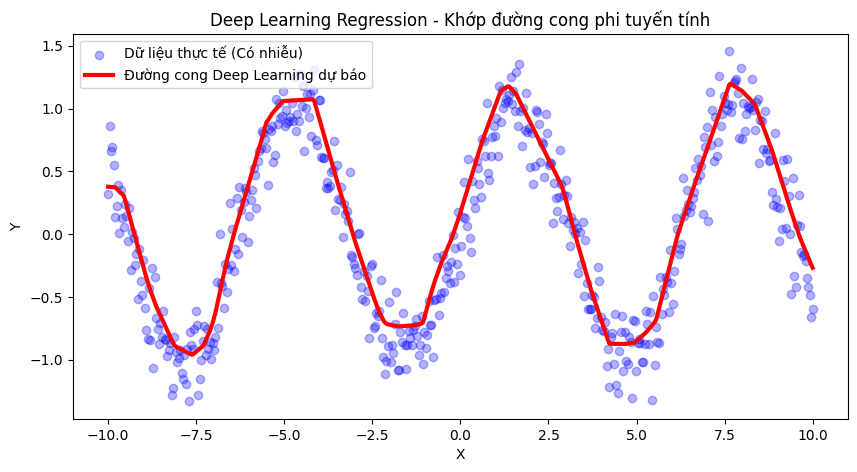

In [42]:
# 5. Đánh giá và trực quan hóa
y_predict = model.predict(X_train)

plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, color='blue', alpha=0.3, label='Dữ liệu thực tế (Có nhiễu)')
plt.plot(X_train, y_predict, color='red', linewidth=3, label='Đường cong Deep Learning dự báo')
plt.title('Deep Learning Regression - Khớp đường cong phi tuyến tính')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

#BAI TAP

In [2]:
#Bai 1
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt

# Tải bộ dữ liệu CIFAR10
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Khai báo mảng tên nhãn (tương ứng với Label từ 0 đến 9 trong bảng của bạn)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Kích thước dữ liệu gốc X_train:", X_train.shape)
print("Kích thước dữ liệu gốc X_test:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Kích thước dữ liệu gốc X_train: (50000, 32, 32, 3)
Kích thước dữ liệu gốc X_test: (10000, 32, 32, 3)


In [3]:
# Chuyển đổi dữ liệu ảnh thành vector 1 chiều (32 * 32 * 3 = 3072)
X_train = X_train.reshape(50000, 3072)
X_test = X_test.reshape(10000, 3072)

# Chuẩn hóa dữ liệu về khoảng [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Kích thước X_train sau khi Reshape:", X_train.shape)

Kích thước X_train sau khi Reshape: (50000, 3072)


In [4]:
# Khởi tạo mô hình
model = Sequential()

# Tầng ẩn 1: 512 nơ-ron, nhận đầu vào có kích thước 3072
model.add(Dense(units=512, activation='relu', input_dim=3072))

# Có thể thêm tầng ẩn 2 để mô hình học sâu hơn
model.add(Dense(units=256, activation='relu'))

# Tầng đầu ra: 10 lớp, dùng softmax để tính xác suất cho 10 loại vật thể
model.add(Dense(units=10, activation='softmax'))

# Biên dịch mô hình
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3263 - loss: 1.8746 - val_accuracy: 0.3734 - val_loss: 1.7285
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4062 - loss: 1.6660 - val_accuracy: 0.4194 - val_loss: 1.6500
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4320 - loss: 1.5913 - val_accuracy: 0.4238 - val_loss: 1.6282
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4556 - loss: 1.5293 - val_accuracy: 0.4564 - val_loss: 1.5342
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4668 - loss: 1.4998 - val_accuracy: 0.4698 - val_loss: 1.4979
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4796 - loss: 1.4571 - val_accuracy: 0.4690 - val_loss: 1.4998
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4883 - loss: 1.4320 - val_accuracy: 0.4640 - val_loss: 1.5034
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4972 - loss: 1.4102 - val_accuracy: 0.

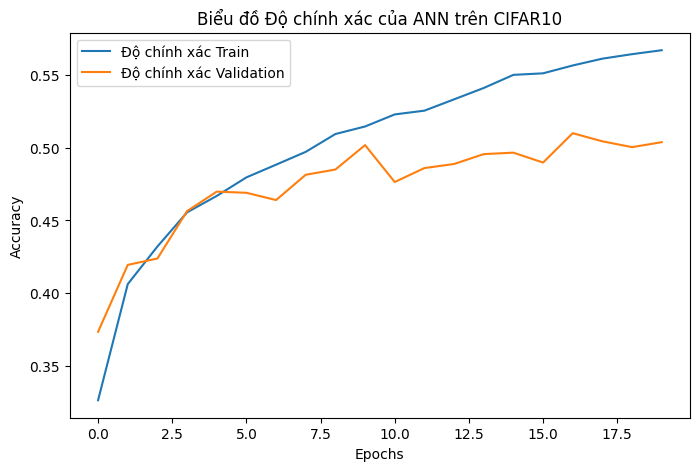

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Dự đoán của mô hình: cat (Label 3)
Nhãn thực tế: deer (Label 4)


In [5]:
# Huấn luyện mô hình
history = model.fit(X_train, y_train, epochs=20, validation_split=0.1, batch_size=64)

# Trực quan hóa độ chính xác
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Độ chính xác Train')
plt.plot(history.history['val_accuracy'], label='Độ chính xác Validation')
plt.title('Biểu đồ Độ chính xác của ANN trên CIFAR10')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Dự báo thử một ảnh trong tập Test
sample_idx = 100
predicted_label = np.argmax(model.predict(X_test)[sample_idx])
true_label = int(y_test[sample_idx][0])

print(f"\nDự đoán của mô hình: {class_names[predicted_label]} (Label {predicted_label})")
print(f"Nhãn thực tế: {class_names[true_label]} (Label {true_label})")